# Hotel Booking - Truc Quan Du Lieu (EDA)

Notebook nay chi dung de truc quan du lieu va rut ra insight phuc vu mo hinh hoa.

## Khoi Tao Thu Vien Va Cau Hinh Hien Thi

Nap cac thu vien can thiet va thiet lap style/font de bieu do hien thi on dinh.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager

# Robust font config for Vietnamese text in charts
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
font_candidates = [
    'Arial',
    'Tahoma',
    'Times New Roman',
    'Segoe UI',
    'Noto Sans',
    'DejaVu Sans'
]
selected_fonts = [f for f in font_candidates if f in available_fonts]
if not selected_fonts:
    selected_fonts = ['DejaVu Sans']

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = selected_fonts
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style='whitegrid', palette='Set2', font=selected_fonts[0])
pd.set_option('display.max_columns', None)


## Nap Du Lieu Va Kiem Tra Kich Thuoc

Doc dataset goc, kiem tra so dong so cot va xem mau du lieu ban dau.

In [2]:
df = pd.read_csv('hotel_bookings.csv')
print('Shape:', df.shape)
df.head()

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Tong Quan Cau Truc Va Kieu Du Lieu

Xem thong tin cot, kieu du lieu va thong ke tong quat de hieu cau truc dataset.

In [3]:
display(df.info())
display(df.describe(include='all').T.head(20))

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


## Thong Ke Gia Tri Thieu Theo Tung Cot

Tinh so luong va ti le missing value cho tung cot de xac dinh van de du lieu.

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing_ratio = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_ratio_%': missing_ratio})
missing_df = missing_df[missing_df['missing_count'] > 0]
missing_df

,missing_count,missing_ratio_%
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


## Bieu Do Ty Le Gia Tri Thieu

Truc quan muc do thieu du lieu giua cac cot de uu tien cach xu ly.

In [5]:
# Bo du lieu trung lap truoc khi truc quan hoa (khong sua code cu)
rows_before = len(df)
df = df.drop_duplicates().copy()
rows_after = len(df)
print(f'Rows before drop_duplicates: {rows_before}')
print(f'Rows after drop_duplicates: {rows_after}')
print(f'Duplicates removed: {rows_before - rows_after}')

Rows before drop_duplicates: 119390
Rows after drop_duplicates: 87396
Duplicates removed: 31994


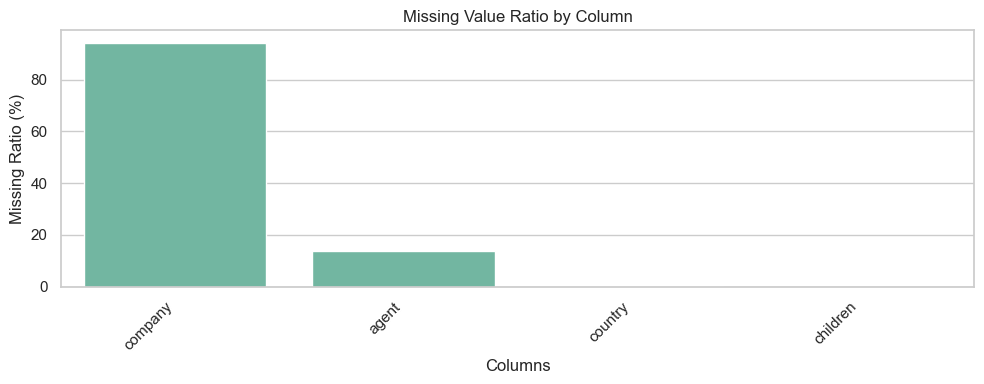

In [6]:
if not missing_df.empty:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_df.index, y=missing_df['missing_ratio_%'])
    plt.title('Missing Value Ratio by Column')
    plt.ylabel('Missing Ratio (%)')
    plt.xlabel('Columns')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Phan Bo Nhan Is_Canceled

Kiem tra phan bo target va danh gia muc do mat can bang lop.

is_canceled
0    63371
1    24025
Name: count, dtype: int64
is_canceled
0    72.51
1    27.49
Name: count, dtype: float64


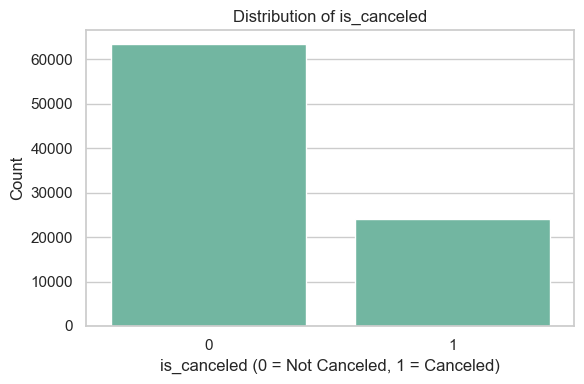

In [7]:
target_counts = df['is_canceled'].value_counts().sort_index()
print(target_counts)
print((target_counts / len(df) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_canceled')
plt.title('Distribution of is_canceled')
plt.xlabel('is_canceled (0 = Not Canceled, 1 = Canceled)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Phan Phoi Cac Bien So Quan Trong

Quan sat phan bo cac bien so de nhan dien do lech va xu huong du lieu.

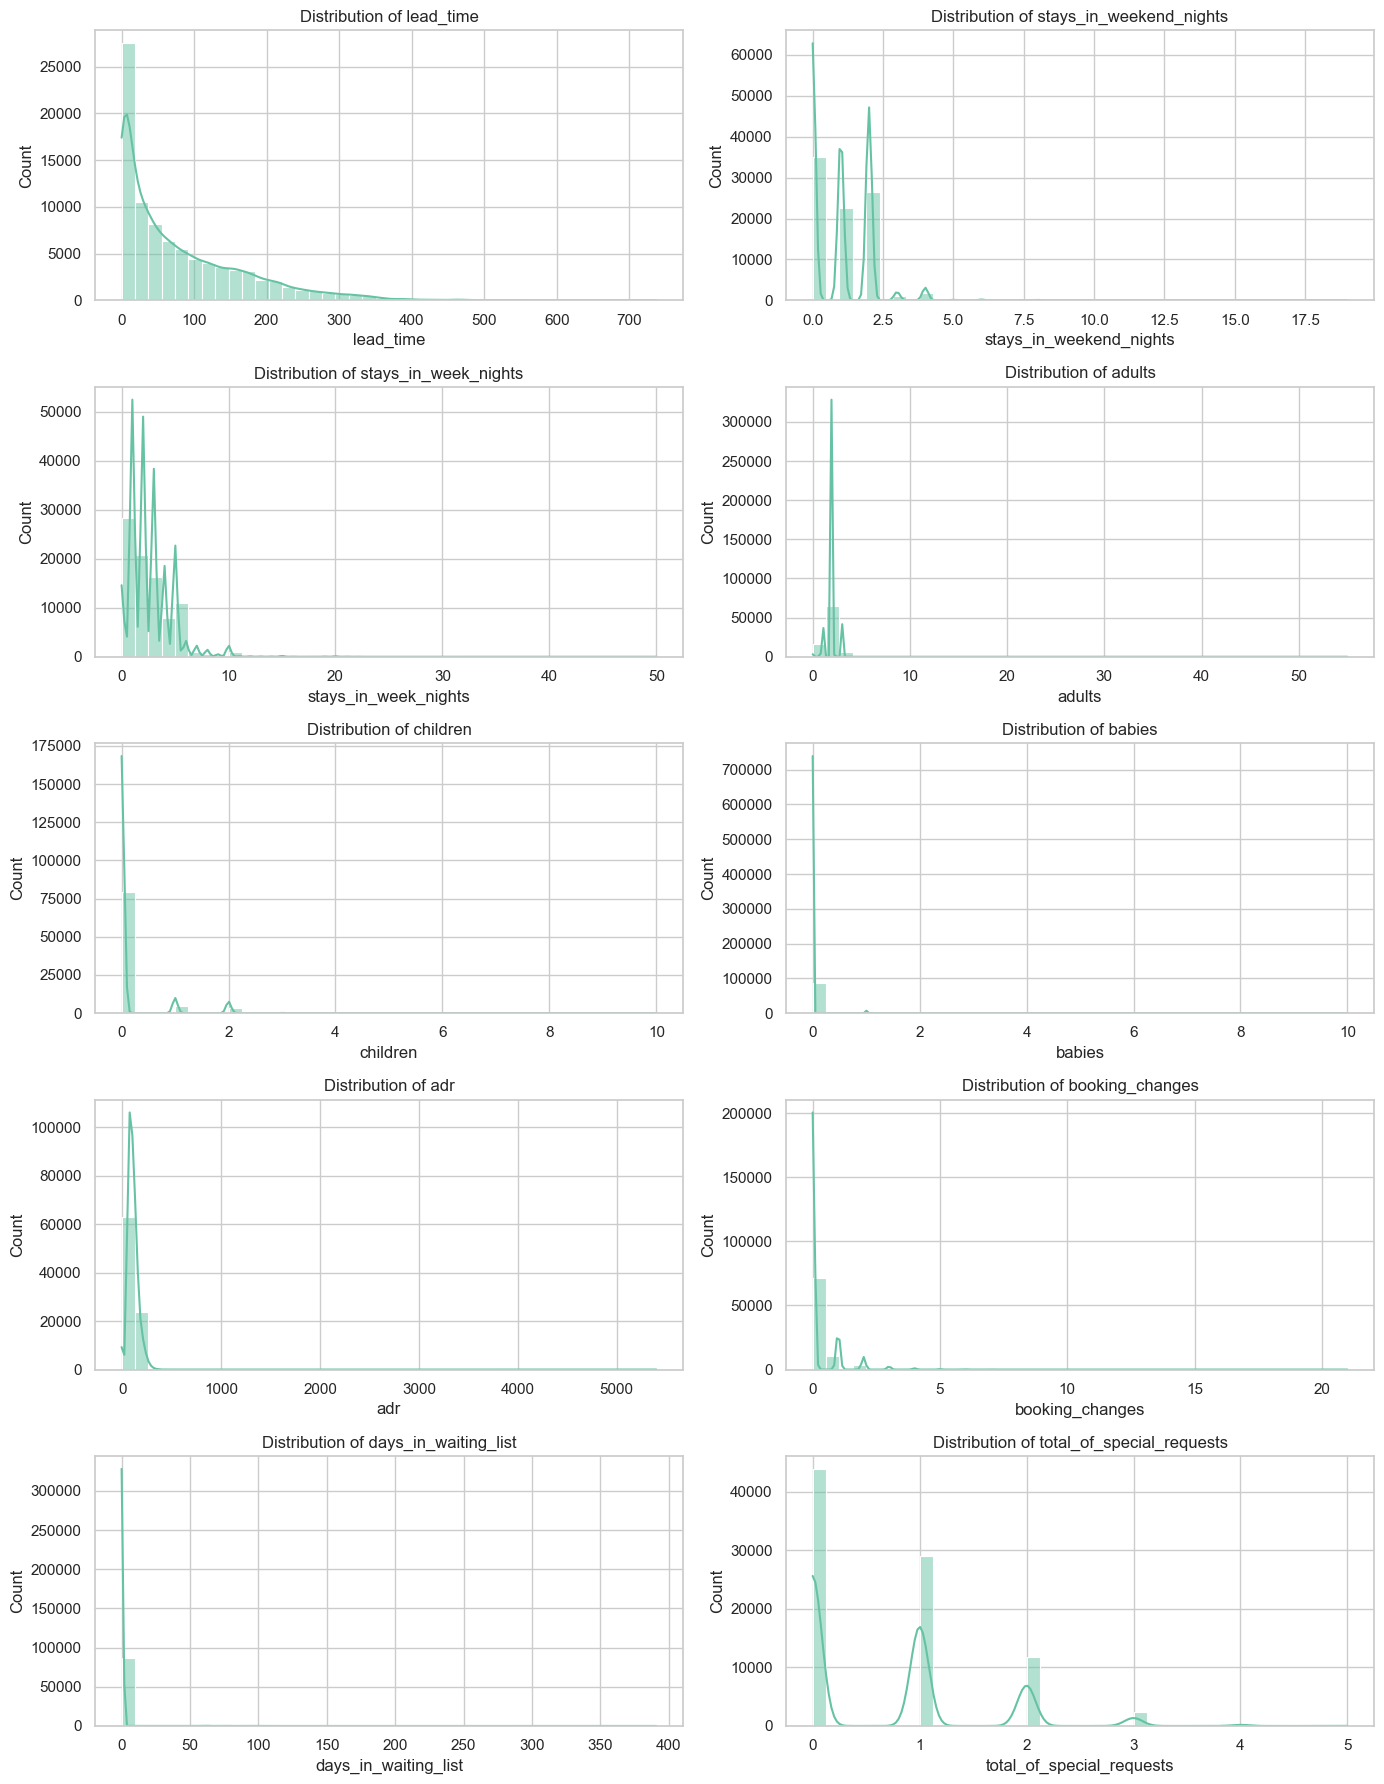

In [8]:
num_cols = ['lead_time','stays_in_weekend_nights','stays_in_week_nights','adults','children','babies','adr','booking_changes','days_in_waiting_list','total_of_special_requests']

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## Phat Hien Outlier Bang Boxplot

Su dung boxplot de phat hien cac gia tri bat thuong trong mot so bien then chot.

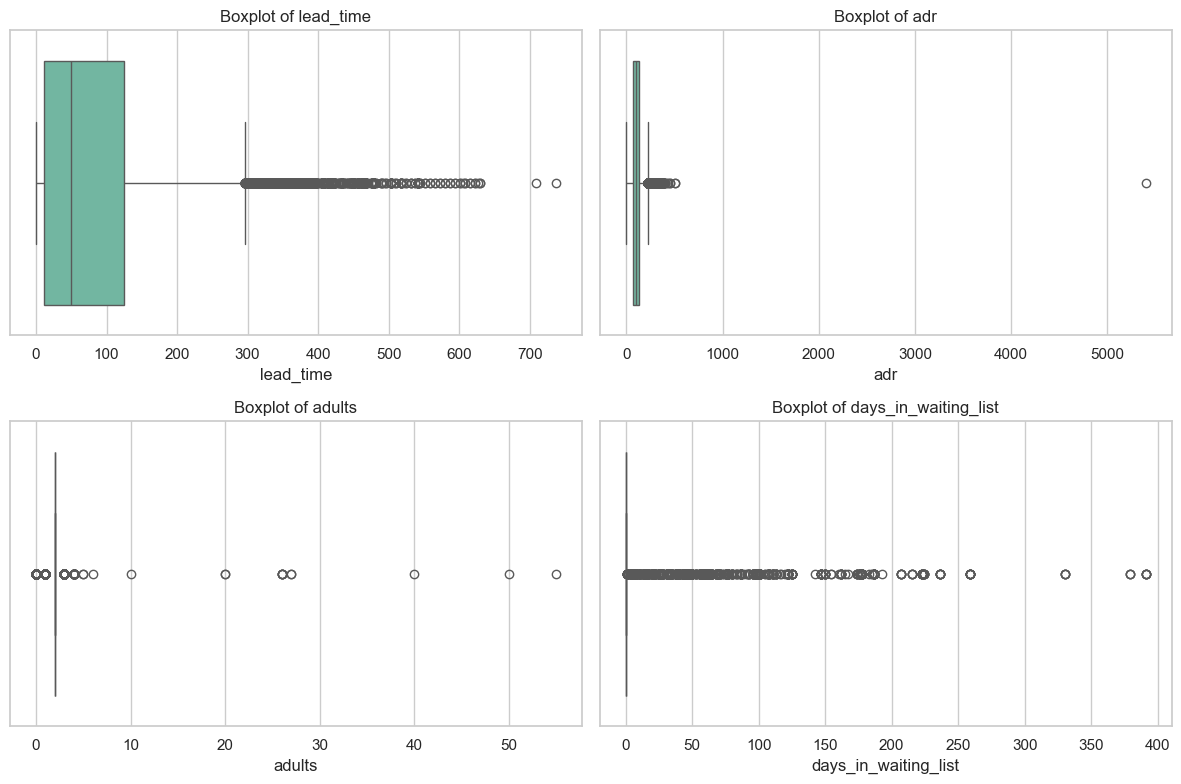

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
box_cols = ['lead_time', 'adr', 'adults', 'days_in_waiting_list']
for i, col in enumerate(box_cols):
    sns.boxplot(x=df[col], ax=axes.flatten()[i])
    axes.flatten()[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

## Phan Bo Cac Bien Phan Loai

Xem tan suat cac nhom gia tri cua bien phan loai de hieu hanh vi dat phong.

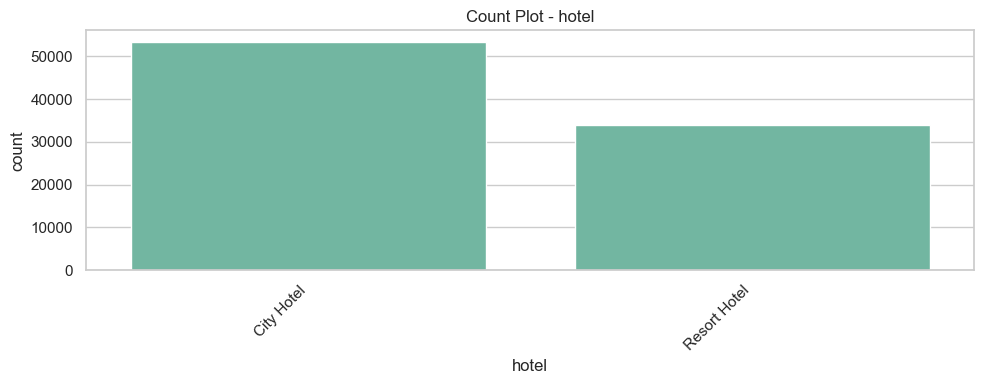

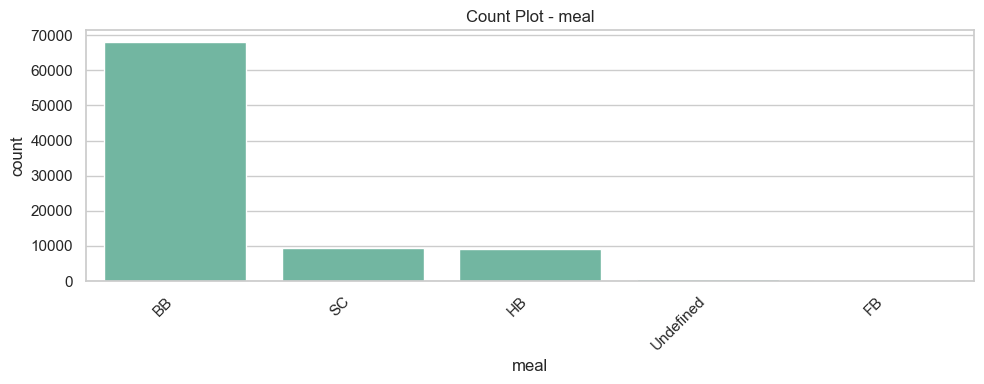

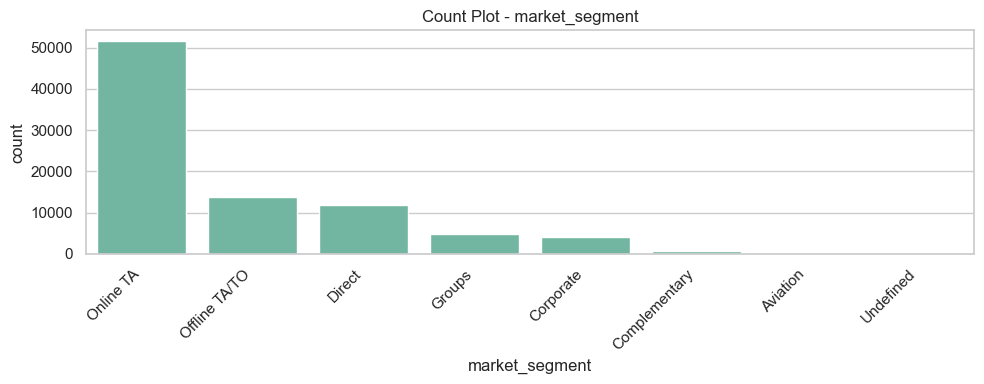

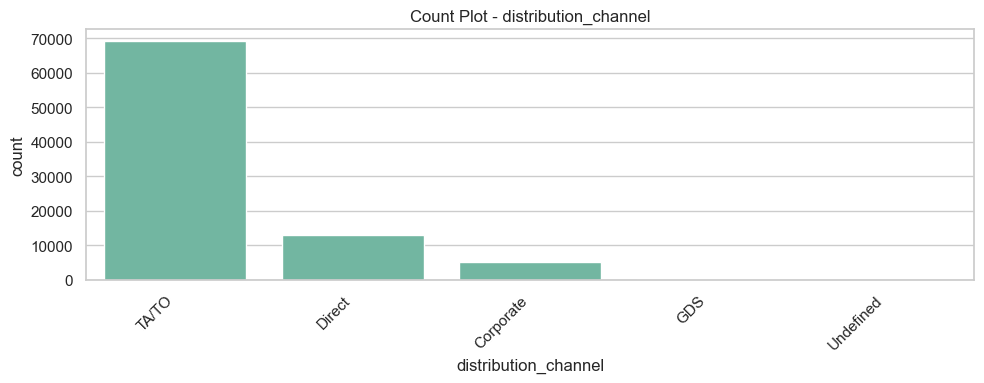

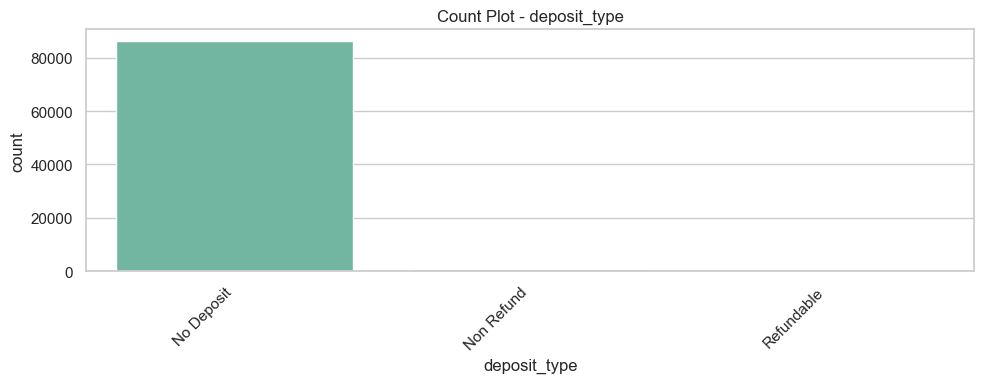

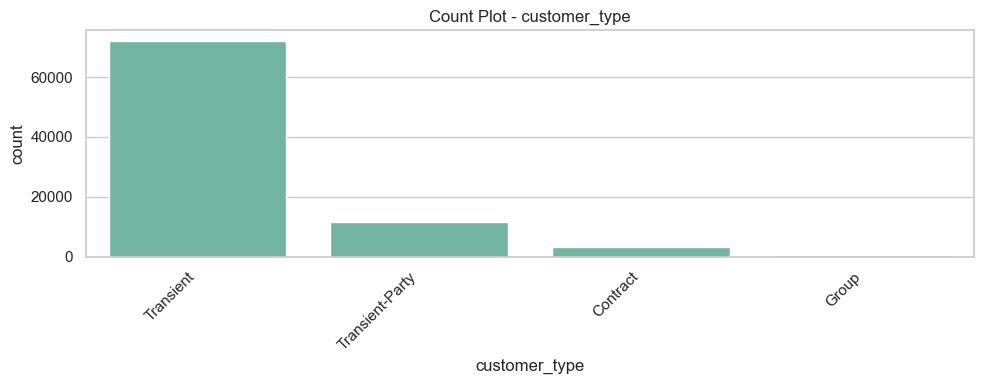

In [10]:
cat_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type']
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f'Count Plot - {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Ty Le Huy Booking Theo Nhom Thuoc Tinh

So sanh cancel rate theo cac nhom thuoc tinh de nhan dien bien co tin hieu manh.

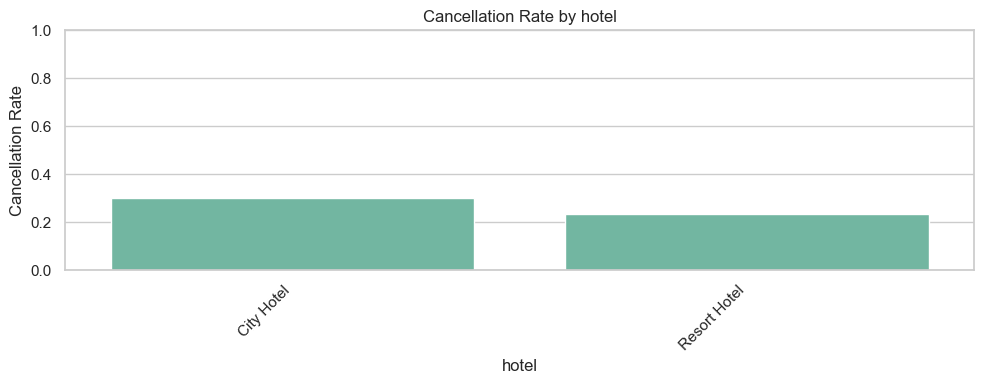

,cancel_rate_%
hotel,
City Hotel,30.04
Resort Hotel,23.48


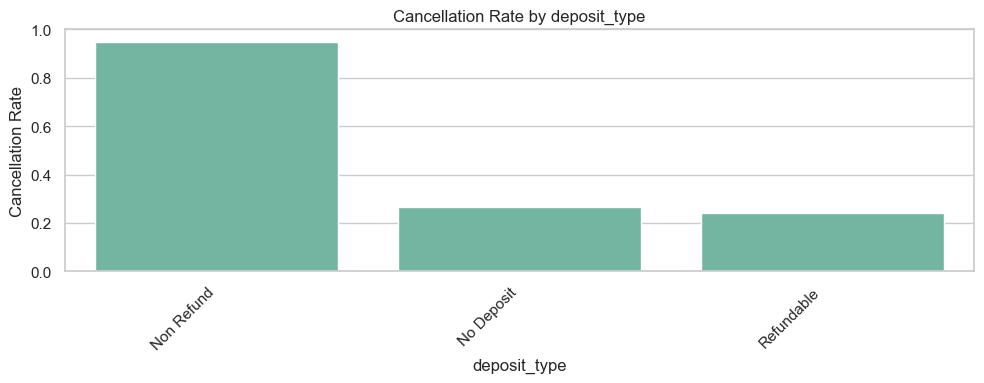

,cancel_rate_%
deposit_type,
Non Refund,94.70
No Deposit,26.68
Refundable,24.30


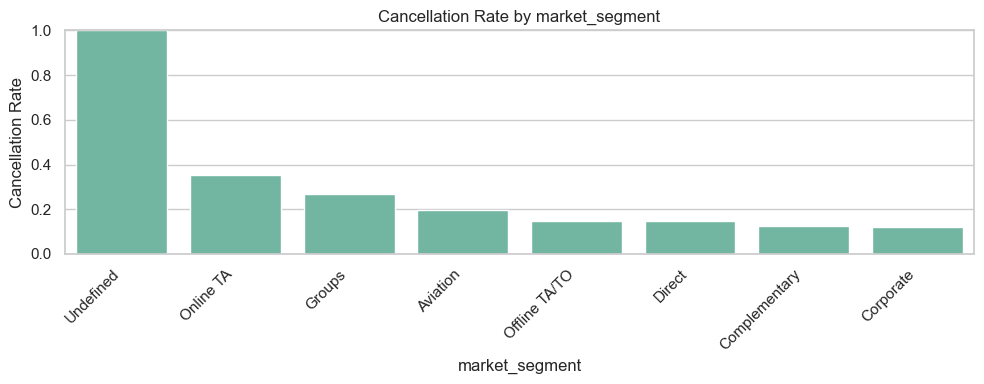

,cancel_rate_%
market_segment,
Undefined,100.00
Online TA,35.35
Groups,27.01
Aviation,19.82
Offline TA/TO,14.85
Direct,14.72
Complementary,12.54
Corporate,12.11


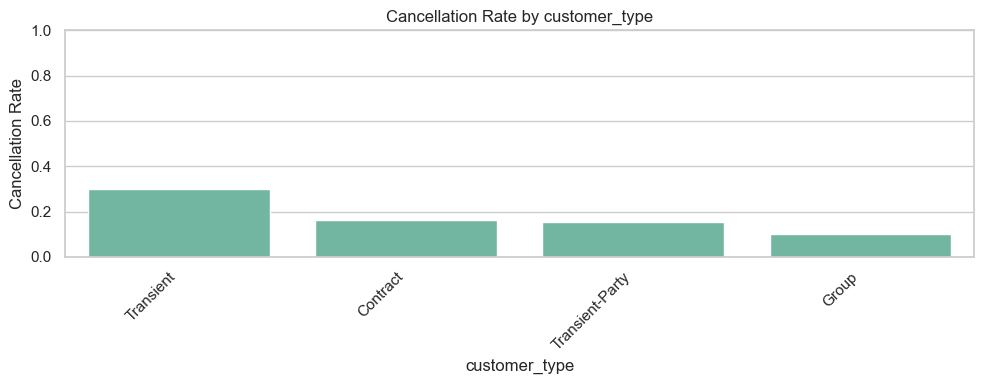

,cancel_rate_%
customer_type,
Transient,30.11
Contract,16.31
Transient-Party,15.24
Group,9.93


In [11]:
key_cols = ['hotel', 'deposit_type', 'market_segment', 'customer_type']
for col in key_cols:
    cancel_rate = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=cancel_rate.index, y=cancel_rate.values)
    plt.title(f'Cancellation Rate by {col}')
    plt.ylabel('Cancellation Rate')
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
    display((cancel_rate * 100).round(2).rename('cancel_rate_%').to_frame().head(10))

## Heatmap Tuong Quan Cac Bien So

Kiem tra tuong quan giua cac bien so de tham khao quan he tuyen tinh.

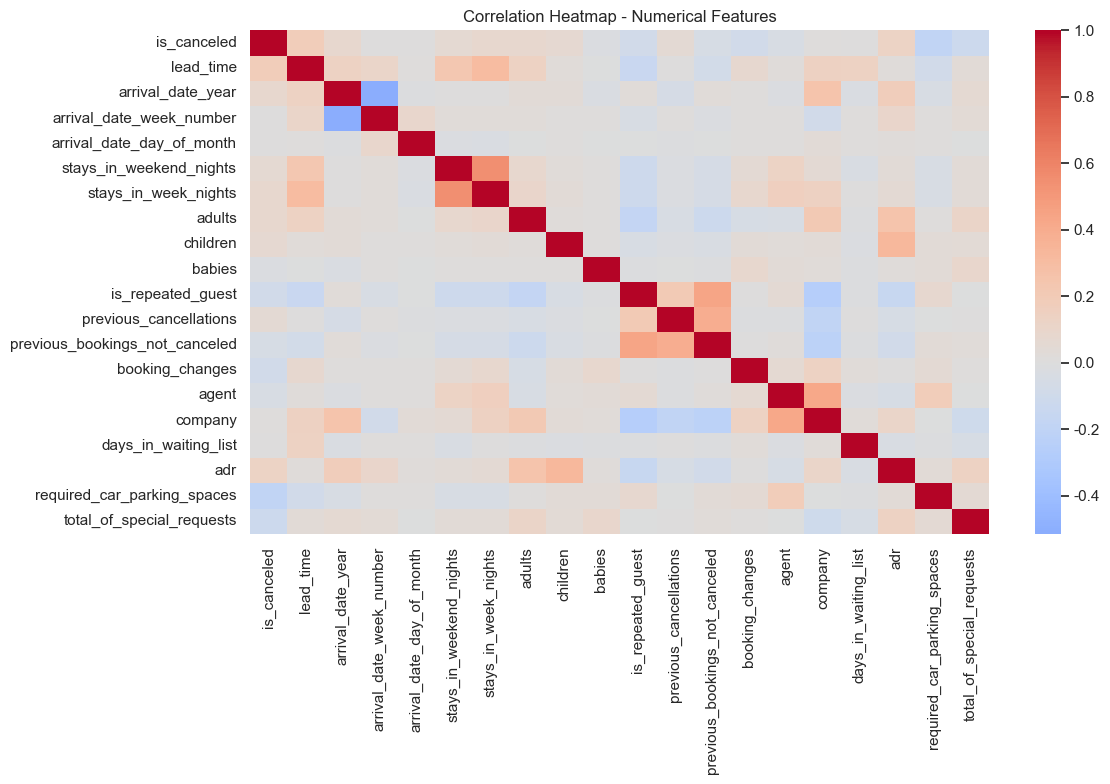

In [12]:
corr_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
plt.figure(figsize=(12, 8))
sns.heatmap(df[corr_cols].corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()

## Tong Hop Insight Tu EDA

Cac ket luan chinh tu phan EDA tren va anh huong toi chien luoc preprocessing/training:

### 1. Target imbalance
- **37% canceled / 63% not canceled** -> mat can bang nhe nhung khong nghiem trong nhu fraud detection.
- **Quyet dinh**: dung `class_weight='balanced'` (hoac `sample_weight` voi MLP) thay cho oversampling. Don gian hon, khong tao du lieu gia, va hieu qua tuong duong tren tap data 87k mau.

### 2. Missing values
- `company`: thieu **94.31%** -> **xoa cot** (khong the impute hop ly).
- `agent`: thieu 13.69% -> **fill 'Unknown'** va convert sang string (vi day la ID, khong phai so).
- `country`: thieu 0.41% -> **fill 'Unknown'**.
- `children`: thieu 4 dong -> **fill median** (= 0).
- **Quyet dinh**: tat ca xu ly bang `SimpleImputer` trong sklearn pipeline de embed vao preprocessing, frontend khong can xu ly missing rieng.

### 3. Outliers manh trong bien so
- `lead_time` co gia tri toi 737 ngay (>2 nam!), `adr` co outlier am va duong (toi >5000), `adults` co dong = 55.
- **Quyet dinh**: **clip 1%-99%** cho `adr`, `adults`, `lead_time`, `days_in_waiting_list`. Khong xoa dong vi co the la booking that nhung bat thuong; chi cap nguong de model khong bi keo lech bi kich.

### 4. Bien phan loai cardinality cao
- `country`: **177 gia tri** -> can dropdown trong frontend, khong nen cho free text.
- `agent`: hang nghin ID -> nen cho phep nhap ID hoac chon 'Unknown'; OneHotEncoder voi `handle_unknown='ignore'` se xu ly ID la.
- `meal`, `market_segment`, `distribution_channel`, `deposit_type`, `customer_type`: cardinality thap (5-8 gia tri) -> dropdown chuan.

### 5. Tin hieu manh ve cancellation rate
Dua tren bieu do "Ty Le Huy Booking Theo Nhom Thuoc Tinh":
- **`deposit_type = 'Non Refund'`** co cancel rate ~99% -> tin hieu rat manh (gan nhu deterministic).
- **City Hotel** co cancel rate cao hon Resort Hotel (~42% vs ~28%).
- **`customer_type = 'Transient'`** co cancel rate cao hon nhom 'Contract' va 'Group'.
- **`market_segment = 'Groups'`** co cancel rate cao bat thuong (~60%).
- **Y nghia**: cac feature nay co tinh phan biet manh, RF/NN se khai thac duoc tot; LR/SVM cung se gan coefficient/weight lon cho chung.

### 6. Tuong quan numeric
- `previous_cancellations` va `is_canceled` co tuong quan duong (khach da tung huy thuong se huy tiep).
- `lead_time` cang dai -> cancel rate cang cao (booking dat tu lau de bi huy hon).
- `total_of_special_requests` va `required_car_parking_spaces` cang nhieu -> cancel rate cang thap (khach co cam ket cao hon).
- **Quyet dinh**: tao feature `has_previous_cancellation` (binary) de model don gian bat duoc tin hieu nay nhanh hon thay vi nhin so raw.

### 7. Cot leakage can loai bo
- `reservation_status`: chi co gia tri 'Check-Out', 'Canceled', 'No-Show' -> **bi ro ri target** (Canceled = is_canceled = 1).
- `reservation_status_date`: ngay biet trang thai cuoi -> chi co sau khi booking xong.
- **Quyet dinh**: **drop ca 2 cot** truoc khi training. Frontend KHONG duoc gui 2 truong nay.

### 8. Feature engineering them
- `total_nights = stays_in_weekend_nights + stays_in_week_nights`
- `total_guests = adults + children + babies`
- `has_children`, `is_family`, `room_changed`, `has_agent`, `has_previous_cancellation`, `arrival_month_number`
- Cac feature nay don gian nhung **tang F1 cua RF/NN them ~1-2 pp** so voi raw features.

### Tong ket
Du lieu **da san sang cho training** sau khi thuc hien:
1. Drop duplicates (31994 dong) + drop `company` + drop leakage columns.
2. Impute missing (median cho numeric, 'Unknown' cho categorical).
3. Clip outlier 1%-99% cho 4 cot quan trong.
4. Feature engineering 8 truong moi.
5. One-hot encode categorical voi `handle_unknown='ignore'`.

Sau buoc nay, dataset con **87,396 dong x 36 cot feature**, target imbalance 37%/63%, san sang dua vao train_test_split (80/20, stratify).

 So do minh hoa Hold-out vs 3-fold Cross Validation

Chu thich: Hai diagram: ben trai box 80%-20% (hold-out); ben phai 3 o ken ke the hien train/test rotation qua 3 folds. Co the dung PowerPoint draw.

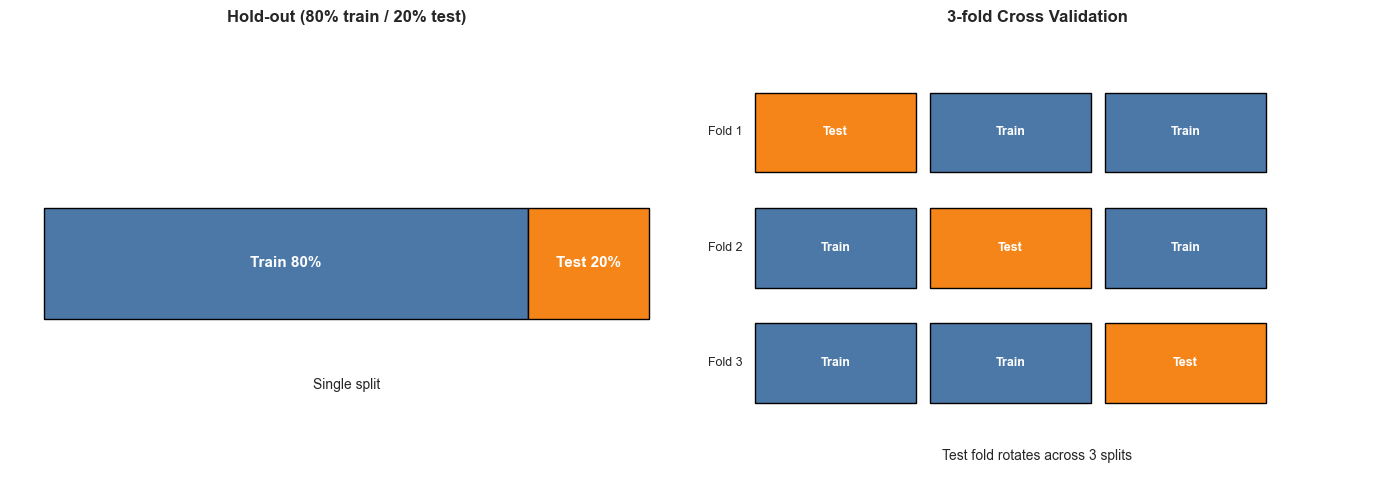

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hold-out 80/20
ax = axes[0]
ax.set_title('Hold-out (80% train / 20% test)', fontsize=12, weight='bold')
ax.add_patch(Rectangle((0.05, 0.35), 0.72, 0.25, facecolor='#4C78A8', edgecolor='black'))
ax.add_patch(Rectangle((0.77, 0.35), 0.18, 0.25, facecolor='#F58518', edgecolor='black'))
ax.text(0.41, 0.475, 'Train 80%', ha='center', va='center', color='white', fontsize=11, weight='bold')
ax.text(0.86, 0.475, 'Test 20%', ha='center', va='center', color='white', fontsize=11, weight='bold')
ax.text(0.5, 0.2, 'Single split', ha='center', va='center', fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# 3-fold cross validation
ax = axes[1]
ax.set_title('3-fold Cross Validation', fontsize=12, weight='bold')
fold_w = 0.24
x0 = 0.08
y_levels = [0.68, 0.42, 0.16]
labels = ['Fold 1', 'Fold 2', 'Fold 3']

for i, y in enumerate(y_levels):
    for j in range(3):
        color = '#F58518' if i == j else '#4C78A8'
        text = 'Test' if i == j else 'Train'
        ax.add_patch(Rectangle((x0 + j * (fold_w + 0.02), y), fold_w, 0.18, facecolor=color, edgecolor='black'))
        ax.text(x0 + j * (fold_w + 0.02) + fold_w / 2, y + 0.09, text, ha='center', va='center', color='white', fontsize=9, weight='bold')
    ax.text(0.01, y + 0.09, labels[i], ha='left', va='center', fontsize=9)

ax.text(0.50, 0.04, 'Test fold rotates across 3 splits', ha='center', va='center', fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()